# Movie Poster classification

In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix


In [2]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


Dataset shape: (7254, 27)

Dataset columns:
['Id', 'Genre', 'Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'N/A', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western']

Sample data:
          Id                                Genre  Action  Adventure  \
0  tt0086425                  ['Comedy', 'Drama']       0          0   
1  tt0085549        ['Drama', 'Romance', 'Music']       0          0   
2  tt0086465                           ['Comedy']       0          0   
3  tt0086567               ['Sci-Fi', 'Thriller']       0          0   
4  tt0086034  ['Action', 'Adventure', 'Thriller']       1          1   

   Animation  Biography  Comedy  Crime  Documentary  Drama  ...  N/A  News  \
0          0          0       1      0            0      1  ...    0     0   
1          0          0       0      0            0      1  ...    0     0

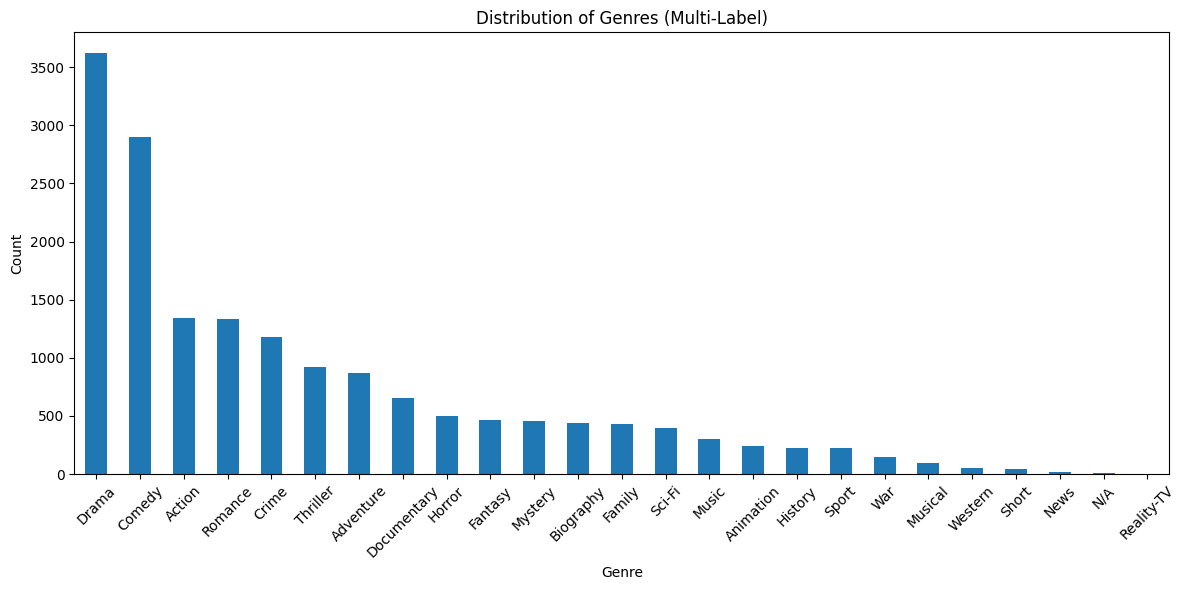

In [4]:
# 1. Data Loading and Preparation
# ===============================

# Load the Excel file
csv_path = r"E:\kaggle moviePoster\dataset\archive\Multi_Label_dataset\train.csv"
df = pd.read_csv(csv_path)

# Basic info
print(f"Dataset shape: {df.shape}")
print("\nDataset columns:")
print(df.columns.tolist())
print("\nSample data:")
print(df.head())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# ===============================
# Updated class distribution plot
# ===============================

# Get binary genre columns
label_columns = df.columns[2:]

# Sum the genre occurrences
genre_counts = df[label_columns].sum().sort_values(ascending=False)

# Plot class distribution
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar')
plt.title('Distribution of Genres (Multi-Label)')
plt.ylabel('Count')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
class MoviePosterDataset(Dataset):
    def __init__(self, dataframe, img_dir, label_columns, transform=None):
        """
        Args:
            dataframe: Pandas dataframe with image Ids and binary label columns
            img_dir: Directory with all the images
            label_columns: List of genre columns (binary) to be used as labels
            transform: Optional transform to be applied to the images
        """
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.label_columns = label_columns
        self.transform = transform
        self.num_classes = len(label_columns)
        self.class_to_idx = {genre: idx for idx, genre in enumerate(label_columns)}
        self.idx_to_class = {idx: genre for genre, idx in self.class_to_idx.items()}
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_filename = str(row['Id']) + '.jpg'  # or '.png' if that's the format
        img_path = os.path.join(self.img_dir, img_filename)

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            image = Image.new('RGB', (224, 224), color='black')
        
        if self.transform:
            image = self.transform(image)
        
        # Multi-hot label vector
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))
        
        return image, labels

In [6]:
# 3. Set up data transformations
# ==============================

# Define transformations for training data (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define transformations for validation/test data (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [7]:
# 4. Split the dataset
# ===================

image_filename_column = 'Id'
target_columns = df.columns[2:]  

# Sanity check
if image_filename_column not in df.columns:
    raise ValueError(f"Column '{image_filename_column}' not found in DataFrame. Available columns: {df.columns.tolist()}")

# Use number of active genres per sample for rough stratification
label_counts = df[target_columns].sum(axis=1)

# Split the dataset
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=label_counts
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

Training set size: 5803
Validation set size: 1451


In [8]:
# 5. Create data loaders
# =====================

img_dir = r"E:\kaggle moviePoster\dataset\archive\Multi_Label_dataset\Images"

# Create datasets
train_dataset = MoviePosterDataset(train_df, img_dir, target_columns, transform=train_transforms)
val_dataset = MoviePosterDataset(val_df, img_dir, target_columns, transform=val_transforms)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)


# Print class distribution information
print(f"\nNumber of classes: {train_dataset.num_classes}")
print("Class mapping:")
for class_name, idx in train_dataset.class_to_idx.items():
    print(f"  {idx}: {class_name}")


Number of classes: 25
Class mapping:
  0: Action
  1: Adventure
  2: Animation
  3: Biography
  4: Comedy
  5: Crime
  6: Documentary
  7: Drama
  8: Family
  9: Fantasy
  10: History
  11: Horror
  12: Music
  13: Musical
  14: Mystery
  15: N/A
  16: News
  17: Reality-TV
  18: Romance
  19: Sci-Fi
  20: Short
  21: Sport
  22: Thriller
  23: War
  24: Western


In [9]:
# 6. Define the model
# ==================

def create_model(num_classes, feature_extract=True):
    """
    Create a pretrained ResNet model with modified final layer for classification
    
    Args:
        num_classes: Number of output classes
        feature_extract: If True, only update the reshaped layer params
    """
    model = models.resnet50(weights='IMAGENET1K_V2')
    
    if feature_extract:
        # Freeze all parameters
        for param in model.parameters():
            param.requires_grad = False
            
    # Replace the final fully connected layer
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    
    return model

# Create the model
model = create_model(train_dataset.num_classes)
model = model.to(device)


In [10]:
# 7. Define loss function and optimizer
# ====================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [13]:
# 8. Training and validation functions
# ==================================

def train_one_epoch(model, dataloader, criterion, optimizer, device, threshold=0.5):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device).float() 

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        # Convert outputs to predictions using threshold
        preds = torch.sigmoid(outputs) > threshold
        running_corrects += torch.sum(preds == labels.bool()).item()
        total_samples += labels.numel()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects / total_samples  # Multi-label accuracy

    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Validating"):
            inputs = inputs.to(device)
            labels = labels.to(device).float()  # Make sure labels are float for BCE

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            # Apply sigmoid and threshold
            preds = torch.sigmoid(outputs) > threshold
            running_corrects += torch.sum(preds == labels.bool()).item()
            total_samples += labels.numel()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects / total_samples  # Multi-label accuracy

    return epoch_loss, epoch_acc



In [15]:
# 9. Train the model
# =================

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    # Track best model
    best_model_wts = model.state_dict()
    best_acc = 0.0
    
    # For tracking metrics
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Train phase
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
        
        # Validation phase
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        print(f'Validation Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
        # Update learning rate
        scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = model.state_dict()
            
        print()
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    
    return model, history

model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)

Epoch 1/10
----------
Train Loss: 5.3935 Acc: 0.7565


Validating:   0%|          | 0/46 [00:00<?, ?it/s]

Validation Loss: 5.3674 Acc: 0.7695

Epoch 2/10
----------
Train Loss: 5.2728 Acc: 0.7670


Validating:   0%|          | 0/46 [00:00<?, ?it/s]

Validation Loss: 5.3172 Acc: 0.7717

Epoch 3/10
----------
Train Loss: 5.1858 Acc: 0.7736


...

Validation Loss: 5.3259 Acc: 0.7857

Epoch 9/10
----------
Train Loss: 4.7040 Acc: 0.7913


Validating:   0%|          | 0/46 [00:00<?, ?it/s]

Validation Loss: 5.3173 Acc: 0.7849

Epoch 10/10
----------
Train Loss: 4.6894 Acc: 0.7914


Validating:   0%|          | 0/46 [00:00<?, ?it/s]

Validation Loss: 5.3109 Acc: 0.7878



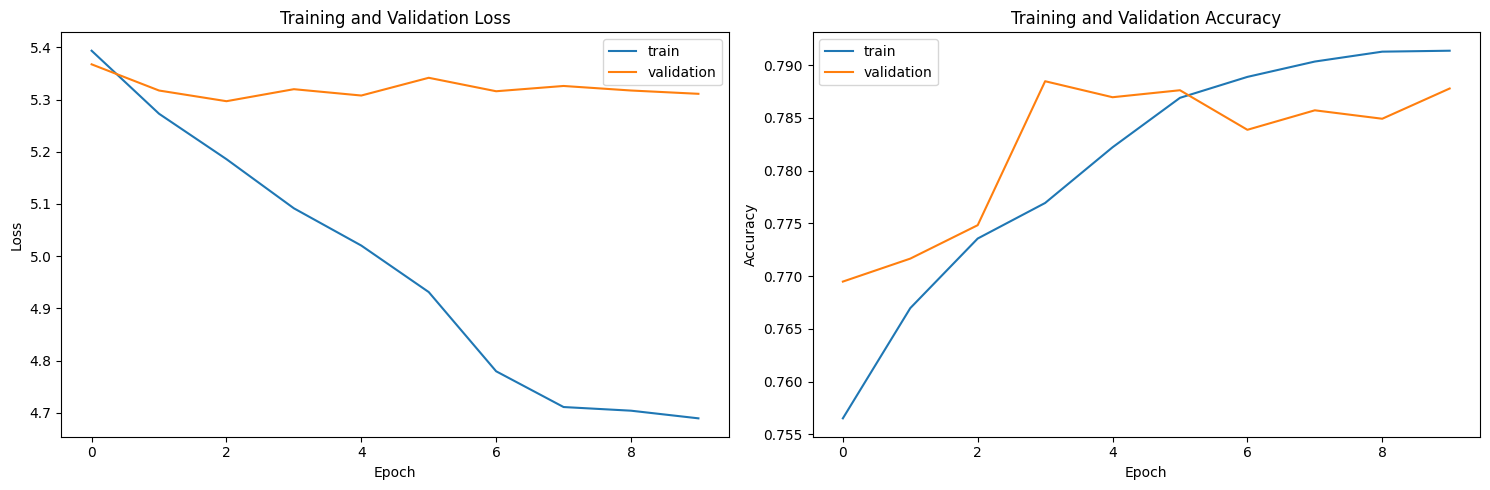

In [16]:
# 10. Plot the training history
# ===========================

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'], label='validation')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    
    # Plot accuracy
    ax2.plot(history['train_acc'], label='train')
    ax2.plot(history['val_acc'], label='validation')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Uncomment after training to visualize results
plot_training_history(history)


In [24]:
# 11. Evaluate the model on validation set
# ======================================

def evaluate_model(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)  # Get probabilities
            preds = (probs > threshold).int()  # Binarize predictions
            
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return all_preds, all_labels


all_preds, all_labels = evaluate_model(model, val_loader, device)

Evaluating:   0%|          | 0/46 [00:00<?, ?it/s]

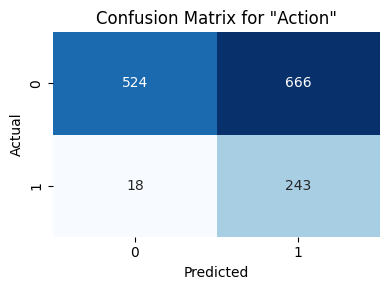

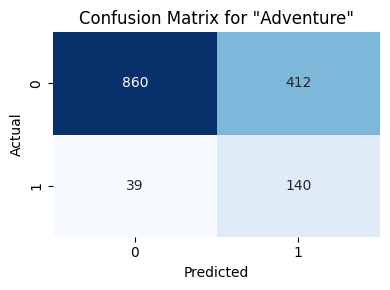

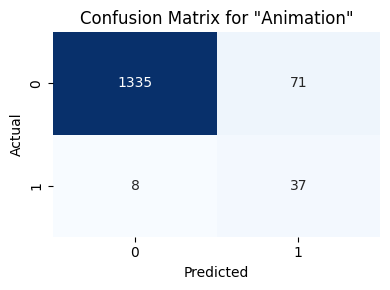

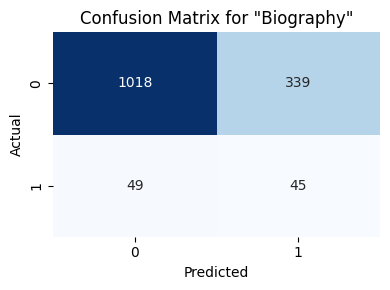

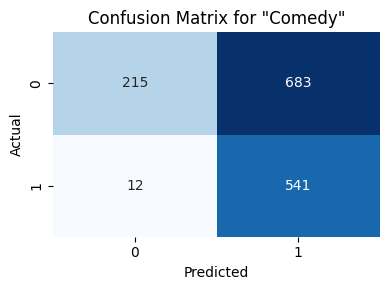

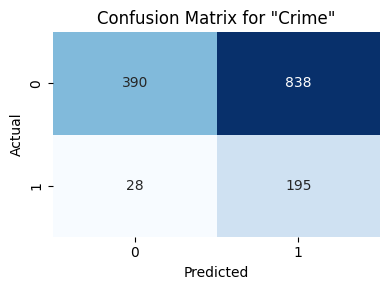

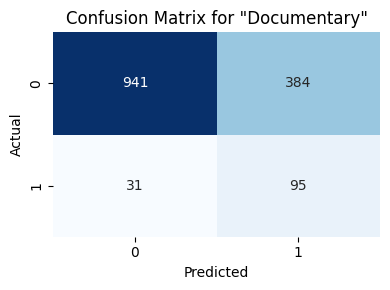

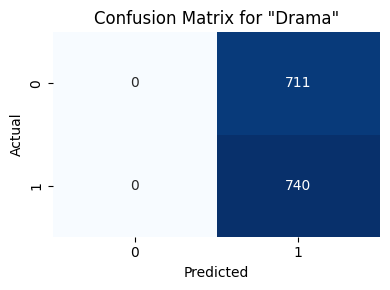

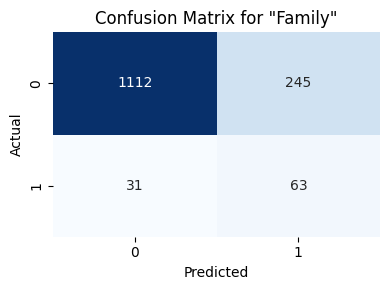

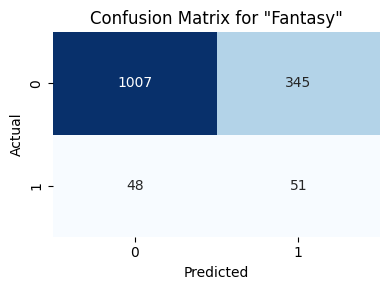

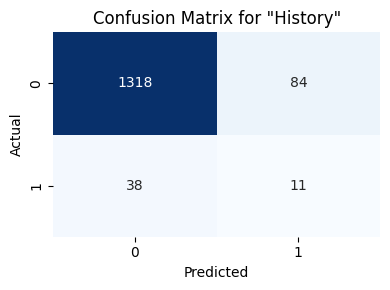

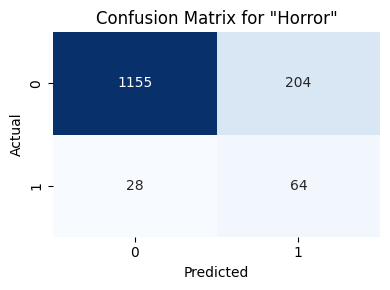

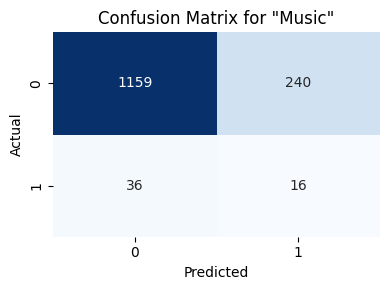

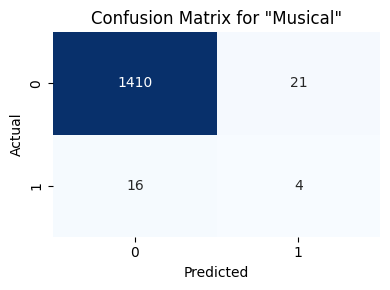

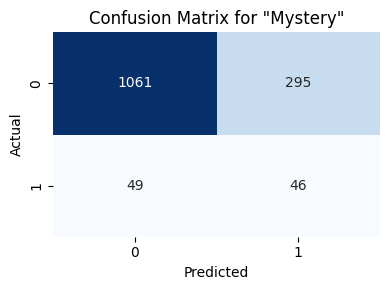

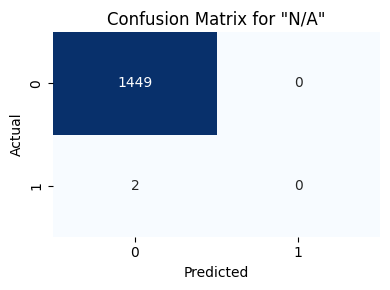

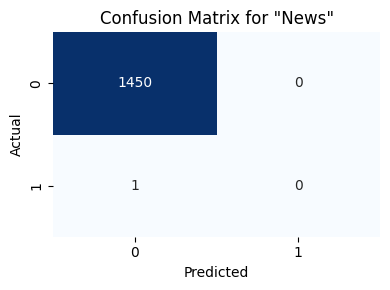

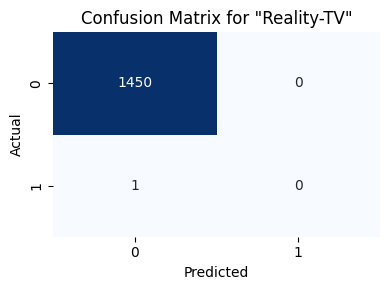

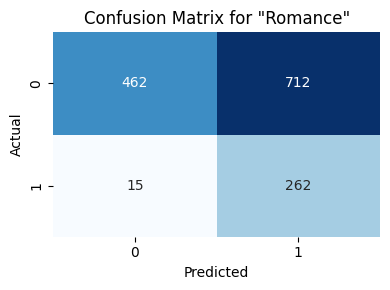

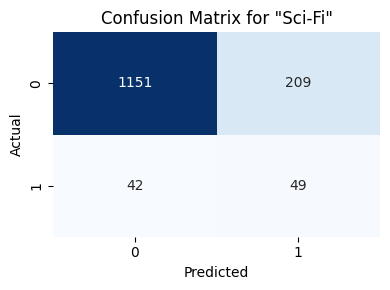

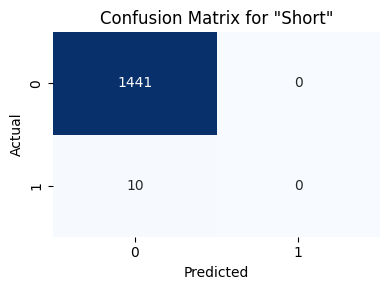

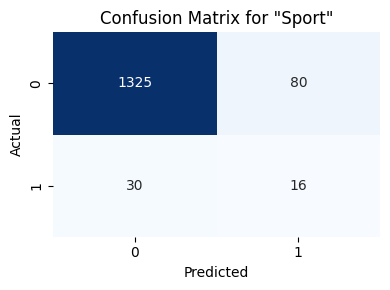

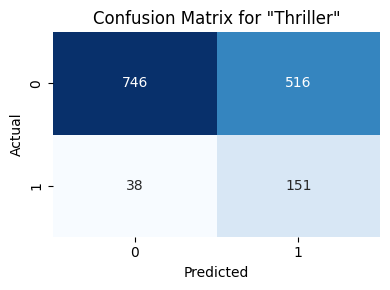

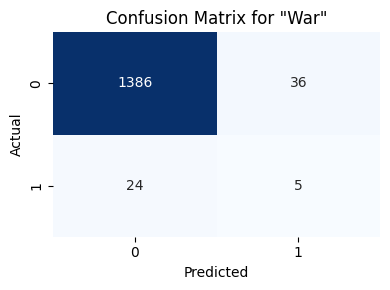

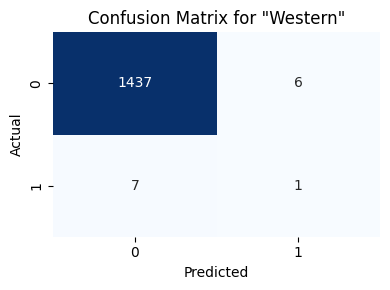

In [25]:
# 12. Plot confusion matrix
# =======================
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

def plot_multilabel_confusion_matrices(y_true, y_pred, class_names):
    for i, class_name in enumerate(class_names):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f'Confusion Matrix for "{class_name}"')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()
        

plot_multilabel_confusion_matrices(all_labels, all_preds, list(train_dataset.idx_to_class.values()))


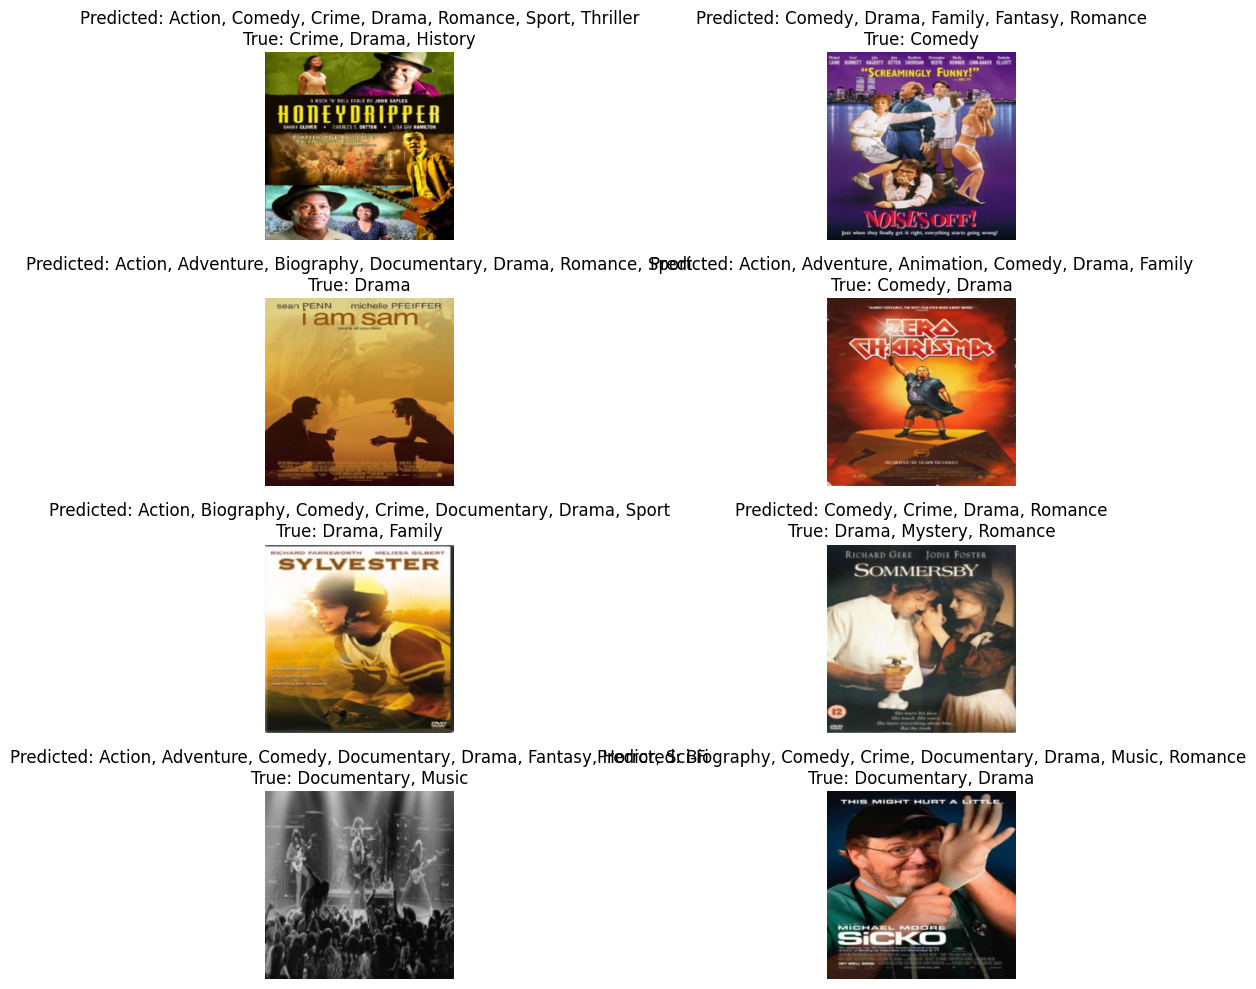

In [27]:
# 13. Visualize model predictions
# =============================

def visualize_predictions(model, dataloader, idx_to_class, device, num_images=8, threshold=0.5):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).int()

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')

                # Decode multi-hot vectors into label names
                true_classes = [idx_to_class[i] for i, val in enumerate(labels[j]) if val == 1]
                pred_classes = [idx_to_class[i] for i, val in enumerate(preds[j]) if val == 1]

                ax.set_title(f'Predicted: {", ".join(pred_classes)}\nTrue: {", ".join(true_classes)}')

                # Convert tensor to image
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)

                plt.imshow(inp)

                if images_so_far == num_images:
                    plt.tight_layout()
                    return
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, val_dataset.idx_to_class, device)


In [28]:
# 14. Save the trained model
# ========================

def save_model(model, filepath='movie_poster_classifier.pth'):
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_to_idx': train_dataset.class_to_idx,
        'idx_to_class': train_dataset.idx_to_class,
        'num_classes': train_dataset.num_classes
    }, filepath)
    print(f"Model saved to {filepath}")

save_model(model)


Model saved to movie_poster_classifier.pth


In [ ]:
# 15. Load the trained model
# ========================

def load_model(filepath='movie_poster_classifier.pth'):
    checkpoint = torch.load(filepath)
    model = create_model(checkpoint['num_classes'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    return model, checkpoint['class_to_idx'], checkpoint['idx_to_class']

# Uncomment to load a previously saved model
# model, class_to_idx, idx_to_class = load_model()


Predicting for image: alien_romulus.jpg
Predicted class: Drama
Top 3 predictions:
  Drama: 15.60%
  Action: 12.10%
  Thriller: 11.35%


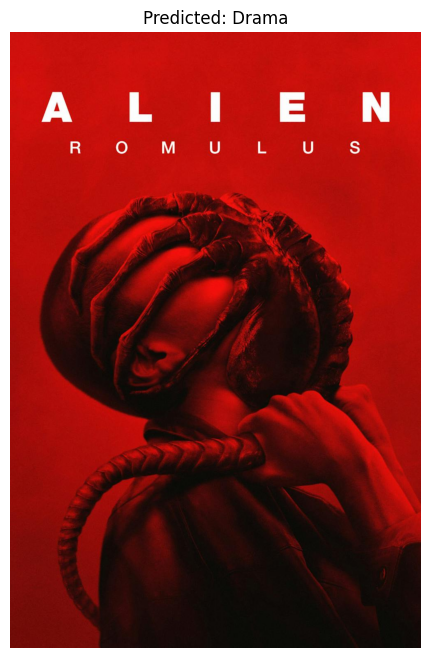


Predicting for image: all_quite_on_the_western_front.jpg
Predicted class: Drama
Top 3 predictions:
  Drama: 31.24%
  Adventure: 13.50%
  Action: 12.63%


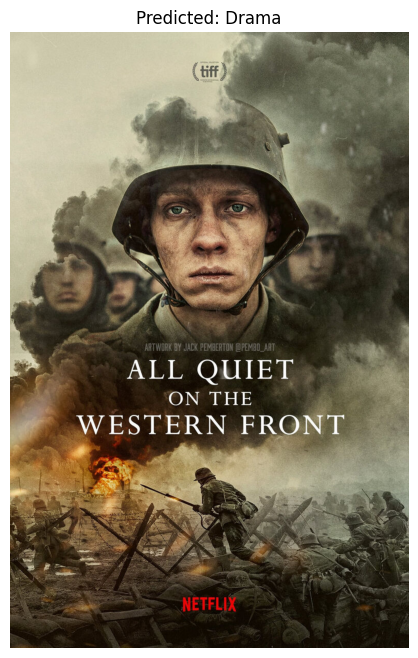


Predicting for image: avengers1.jpg
Predicted class: Adventure
Top 3 predictions:
  Adventure: 52.40%
  Action: 19.16%
  Fantasy: 6.52%


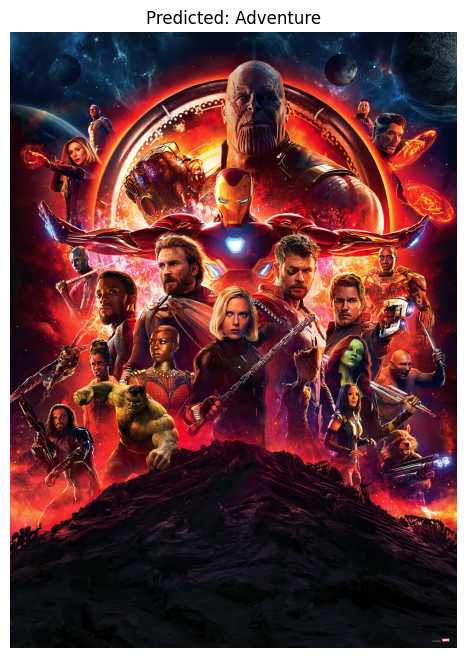


Predicting for image: avengers2.jpg
Predicted class: Adventure
Top 3 predictions:
  Adventure: 32.77%
  Action: 28.23%
  Sci-Fi: 9.17%


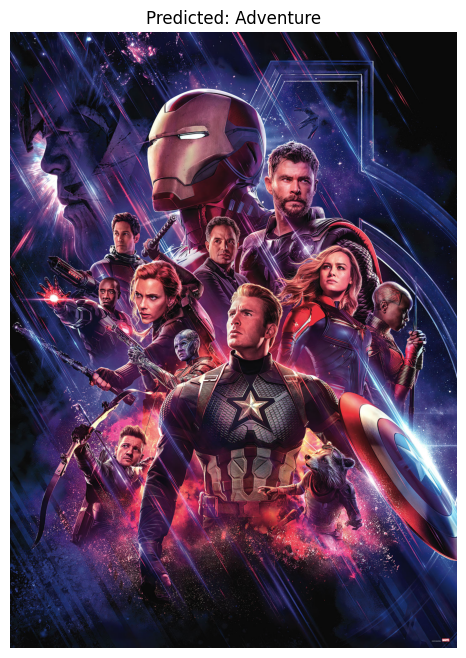


Predicting for image: john_wick_chapter_four.jpg
Predicted class: Adventure
Top 3 predictions:
  Adventure: 21.42%
  Action: 20.32%
  Drama: 14.48%


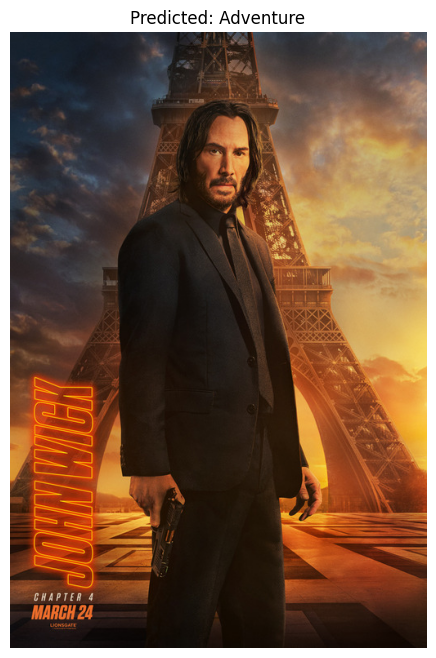


Predicting for image: minecraft.jpg
Predicted class: Comedy
Top 3 predictions:
  Comedy: 45.40%
  Drama: 19.09%
  Romance: 11.14%


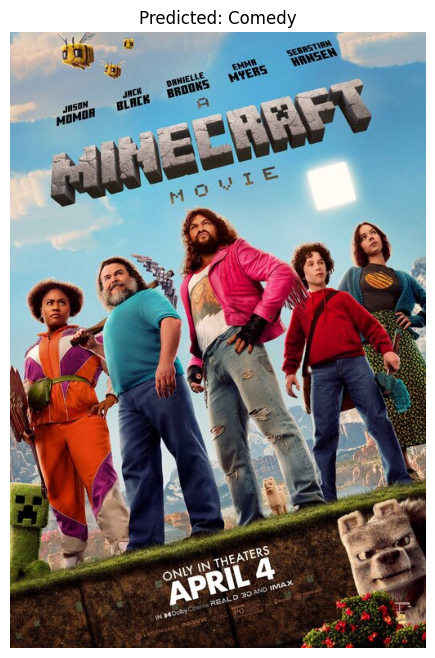


Predicting for image: napoleon.jpg
Predicted class: Action
Top 3 predictions:
  Action: 25.88%
  Drama: 22.01%
  Adventure: 8.77%


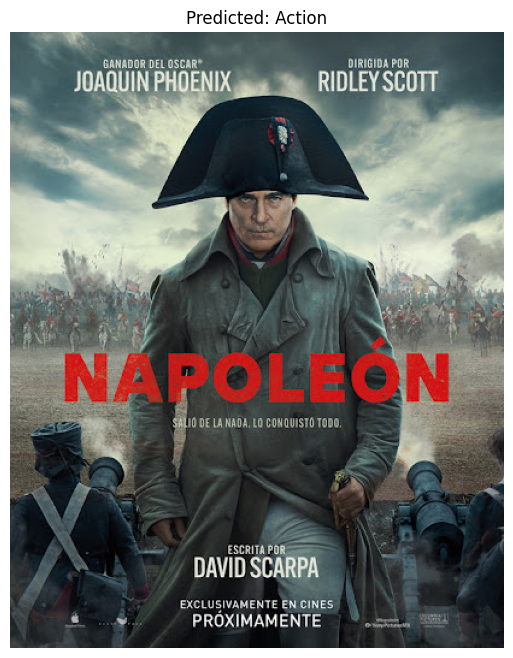


Predicting for image: resident_evil.jpg
Predicted class: Comedy
Top 3 predictions:
  Comedy: 16.28%
  Action: 15.41%
  Crime: 12.96%


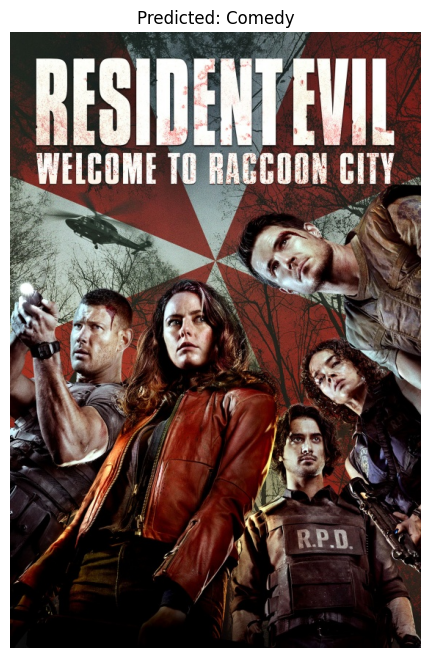


Predicting for image: snow_white.jpg
Predicted class: Adventure
Top 3 predictions:
  Adventure: 28.36%
  Animation: 27.20%
  Comedy: 15.57%


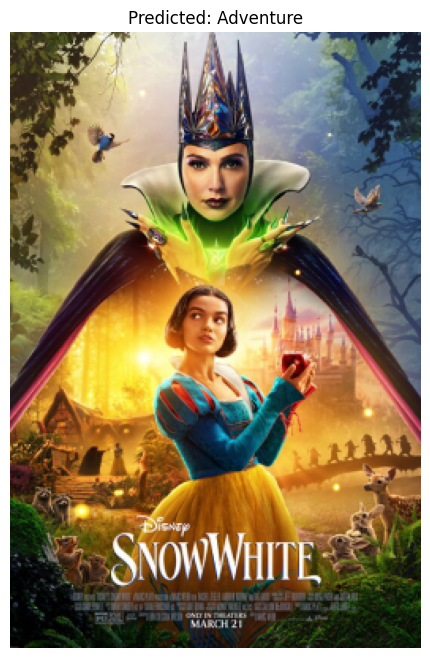


Predicting for image: suzume.jpg
Predicted class: Adventure
Top 3 predictions:
  Adventure: 27.75%
  Action: 13.99%
  Comedy: 12.34%


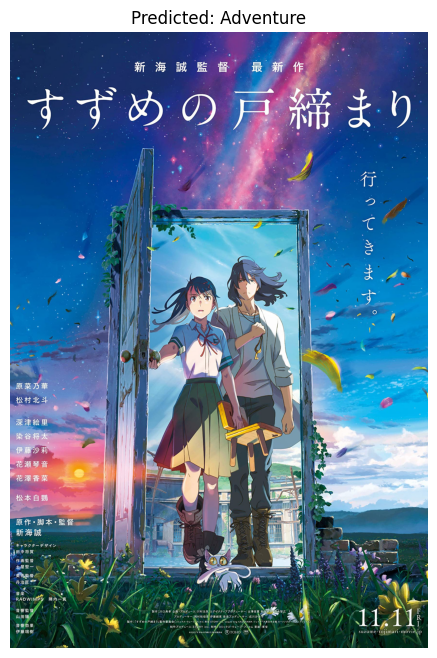

In [37]:
# 16. Function to predict class for a single image
# =============================================

def predict_image(image_path, model, idx_to_class, device):
    """
    Make a prediction for a single image
    """
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    transform = val_transforms
    image = transform(image).unsqueeze(0).to(device)
    
    # Set model to evaluation mode
    model.eval()
    
    # Make prediction
    with torch.no_grad():
        outputs = model(image)
        _, preds = torch.max(outputs, 1)
        predicted_class = idx_to_class[preds.item()]
        
        # Get probabilities
        probs = torch.nn.functional.softmax(outputs, dim=1)
        top_probs, top_classes = torch.topk(probs, 3)
        
    # Display results
    print(f"Predicted class: {predicted_class}")
    print("Top 3 predictions:")
    for i in range(3):
        print(f"  {idx_to_class[top_classes[0][i].item()]}: {top_probs[0][i].item()*100:.2f}%")
    
    # Display the image
    plt.figure(figsize=(8, 8))
    img = Image.open(image_path).convert('RGB')
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
    
    return predicted_class, probs

# Define the function to predict class for images in the test folder
def predict_images_in_folder(test_folder, model, idx_to_class, device):
    # Get a list of all image files in the test folder
    test_images = [f for f in os.listdir(test_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    # Loop through each image in the folder
    for image_file in test_images:
        image_path = os.path.join(test_folder, image_file)
        print(f"\nPredicting for image: {image_file}")
        
        # Call the predict_image function for each image
        predict_image(image_path, model, idx_to_class, device)

# Folder containing the test images
test_folder = r"E:\kaggle moviePoster\dataset\archive\Multi_Label_dataset\tests"

# Call the function to predict for all images in the test folder
predict_images_in_folder(test_folder, model, val_dataset.idx_to_class, device)